In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/lungimagesets.zip" -d "/content/drive/MyDrive/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1900.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1901.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1902.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1903.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1904.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1905.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1906.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1907.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1908.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca1909.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca191.jpeg  
  inflating: /content/drive/MyDrive/lung_image_sets/lung_aca/lungaca19

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/lung_image_sets"

print("Adenocarcinoma:", len(os.listdir(dataset_path + "/lung_aca")))
print("Squamous:", len(os.listdir(dataset_path + "/lung_scc")))
print("Normal:", len(os.listdir(dataset_path + "/lung_n")))

Adenocarcinoma: 2000
Squamous: 2000
Normal: 2000


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/lung_image_sets"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 6000 files belonging to 3 classes.
Using 4800 files for training.
Found 6000 files belonging to 3 classes.
Using 1200 files for validation.


In [ ]:
dataset_path = "/content/drive/MyDrive/lungimagesets.zip"

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(3, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50, batch_size=32
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 43s 231ms/step - accuracy: 0.6568 - loss: 0.8991 - val_accuracy: 0.8567 - val_loss: 0.3878
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.8662 - loss: 0.3272 - val_accuracy: 0.9008 - val_loss: 0.2640
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 216ms/step - accuracy: 0.8803 - loss: 0.2860 - val_accuracy: 0.8983 - val_loss: 0.2233
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 247ms/step - accuracy: 0.9075 - loss: 0.2187 - val_accuracy: 0.9108 - val_loss: 0.2090
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 211ms/step - accuracy: 0.9284 - loss: 0.1751 - val_accuracy: 0.9217 - val_loss: 0.1857
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 210ms/step - accuracy: 0.9387 - loss: 0.1448 - val_accuracy: 0.9150 - val_loss: 0.2456
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - accuracy: 0.9525 - loss: 0.1237 - val_accuracy: 0.9375 - val_loss: 0.1797
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 199ms/step - accuracy: 0.9764 - loss: 0

In [ ]:
model.save("lung_cancer_model.keras")

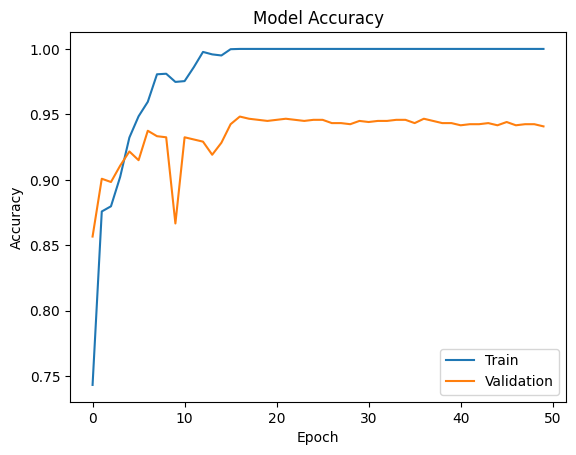

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step


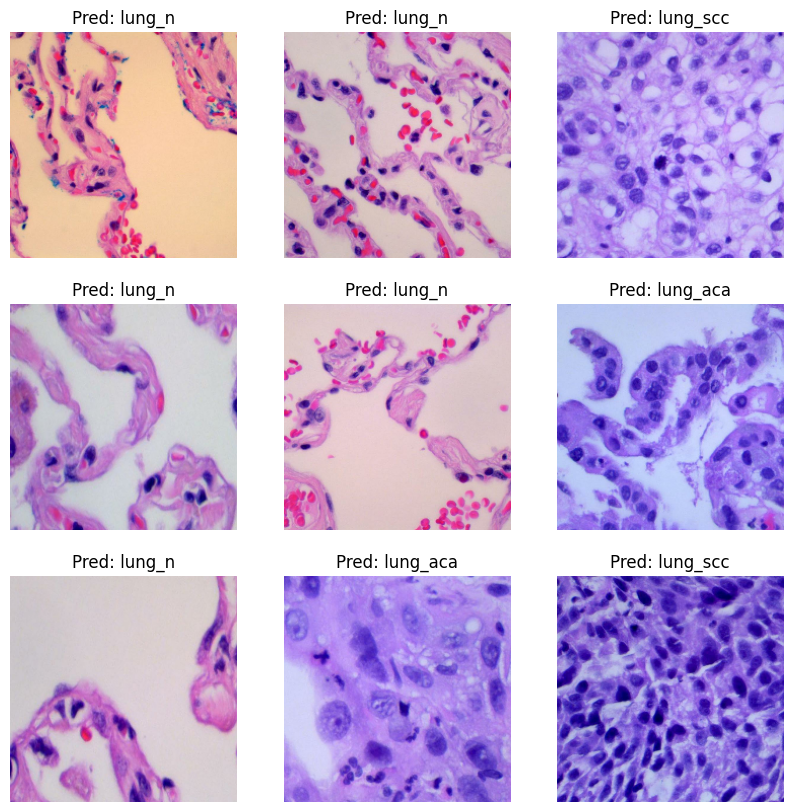

In [ ]:
class_names = train_dataset.class_names

for images, labels in val_dataset.take(1):

    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    plt.figure(figsize=(10,10))

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Pred: " + class_names[preds[i]])
        plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

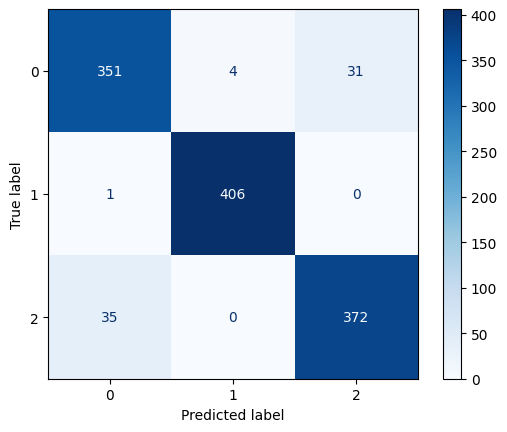

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       386
           1       0.99      1.00      0.99       407
           2       0.92      0.91      0.92       407

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200

